# Machine Learning Classifier for Lung Disease

Air is a fundamental part of our survival and because of this, lung diseases are prevalent given the various airbourne pathogens and complications we may suffer. Alike many other illnesses, medical imaging is used for lung disease and depending on the contents or the appearance of the lung image, we can determine what kind of disease the patient suffers from. In line with thius, we developed a model that can predict the disease given a lung xray image.

## Download Dataset

To begin, we will source the dataset from gunasethwikagone from kaggle

In [6]:
import kagglehub
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from collections import Counter
from PIL import Image

c:\Users\KURT\Git\csc713m-mco\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
path = Path(kagglehub.dataset_download("gunasathwikagone/lung-disease-image-dataset"))
print("Path to dataset files:", path)

dst = Path.cwd() / path.name

shutil.copytree(path, dst, dirs_exist_ok=True)

The dataset is already split for test, validation and training, however for the purposes of different models we will consolidate them into `/dataset-combined`

In [ ]:
splits = ['train', 'test', 'val']
labels = ['COVID-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']

src = "1/dataset_all"
dest = "1/dataset_combined"

if not os.path.exists("1/dataset_combined"):
    os.makedirs(dest)
    print(f"Created directory: {dest}")

for label in labels:
    dest_label_path = os.path.join(dest, label)
    os.makedirs(dest_label_path, exist_ok=True)
    
    for split in splits:
        src_label_path = os.path.join(src, split, label)
        
        if os.path.exists(src_label_path):
            for file in tqdm(os.listdir(src_label_path), desc=f"Copying files from {src_label_path}"):
                src_file = os.path.join(src_label_path, file)
                
                if os.path.isfile(src_file):
                    dest_file = os.path.join(dest_label_path, file)
                    
                    if (not os.path.exists(dest_file)):
                        shutil.copy2(src_file, dest_file)
        else:
            print(f"  Warning: Path {src_label_path} not found. Skipping.")

## Exploratory Data Analysis

Since we are working with image data, the way we explore our data will be through the characteristics of the images, such as the distribution of classes, the resolutions of all images, and the size of each class.

In [ ]:
def list_resolutions(folder_path:str):
    resolutions = []

    for filename in tqdm(os.listdir(folder_path)):
        if filename.lower().endswith(('.jpg')):
            try:
                with Image.open(os.path.join(folder_path, filename)) as img:
                    resolutions.append(f"{img.width}x{img.height}")
            except Exception as e:
                print(f"Could not read {filename}: {e}")

    stats = Counter(resolutions)

    print("Resolution | Count")
    print("-" * 20)
    for res, count in stats.most_common():
        print(f"{res} | {count}")

In [ ]:
list_resolutions("1/dataset_combined/COVID-19")
list_resolutions("1/dataset_combined/Normal")
list_resolutions("1/dataset_combined/Pneumonia-Bacterial")
list_resolutions("1/dataset_combined/Pneumonia-Viral")

In [3]:
def count_images(path):
    entries = os.listdir(path)
    file_count = len([f for f in entries if os.path.isfile(os.path.join(path, f))])
    return file_count

In [7]:
classes = {
    "COVID-19":                 "1/dataset_combined/COVID-19",
    "Normal":                   "1/dataset_combined/Normal",
    "Pneumonia-Bacterial":      "1/dataset_combined/Pneumonia-Bacterial",
    "Pneumonia-Viral":          "1/dataset_combined/Pneumonia-Viral"
}

labels = list(classes.keys())
paths = list(classes.values())
counts = [count_images(p) for p in paths]

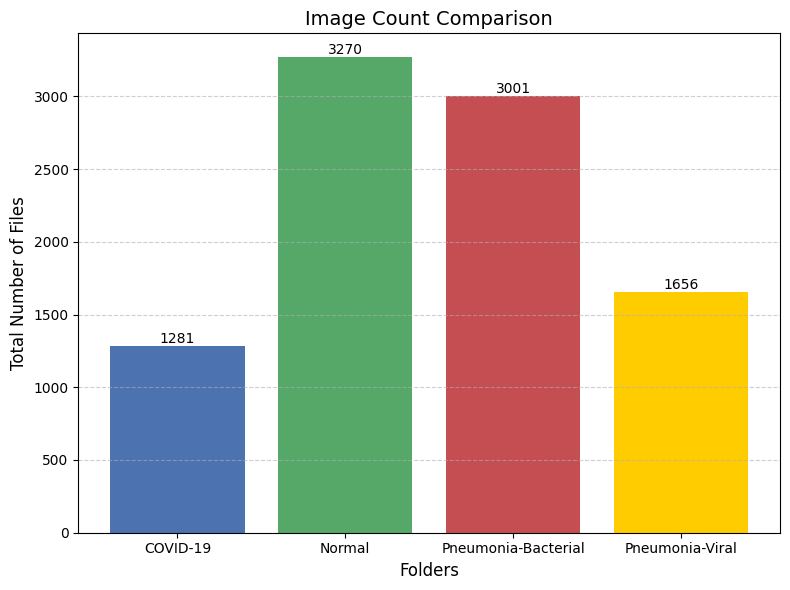

In [8]:
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, counts, color=['#4C72B0', '#55A868', '#C44E52', '#FFCC00'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, yval, ha='center', va='bottom')

plt.xlabel('Folders', fontsize=12)
plt.ylabel('Total Number of Files', fontsize=12)
plt.title('Image Count Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

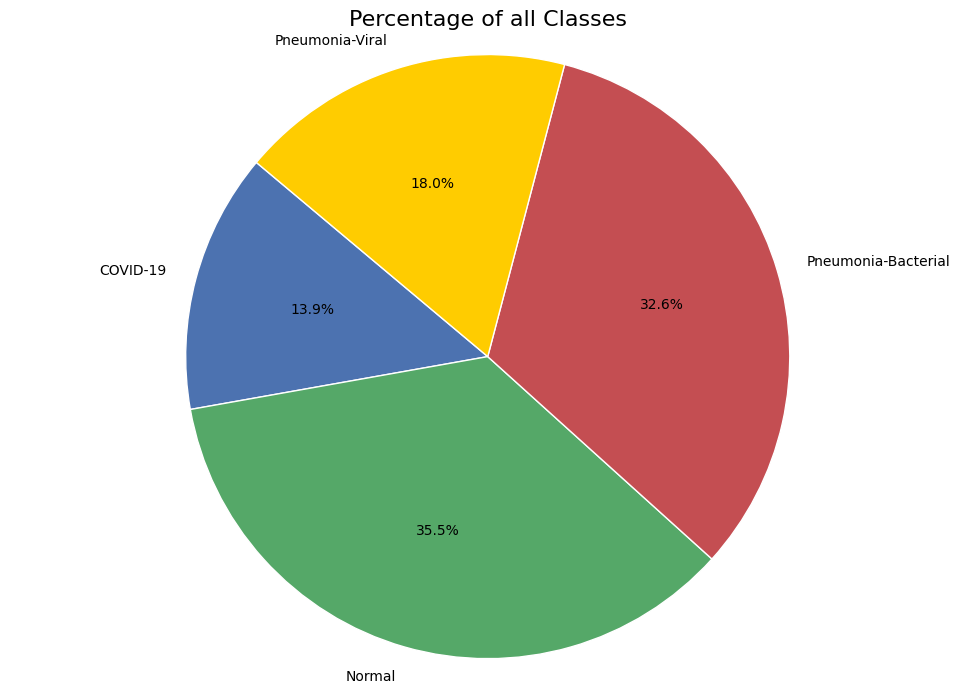

In [9]:
plt.figure(figsize=(10, 7))

colors = ['#4C72B0', '#55A868', '#C44E52', '#FFCC00']

plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
        wedgeprops={'edgecolor': 'white'})

plt.axis('equal') 

plt.title('Percentage of all Classes', fontsize=16)

plt.tight_layout()

As shown with the two plots, we can see that there is a major class imbalance with COVID-19 compared to other classes. This suggests that moving forward it will be required to have stratification within data splitting. 